# The Architecture of Data Integrity — Project 2: Exploratory Data Analysis (EDA)

**Intern Project:** DecodeLabs Internship
**Goal:** Analyze the cleaned e-commerce orders dataset to uncover patterns, trends, and outliers — calculating descriptive statistics, checking distributions, detecting outliers, and translating findings into business insight.

**Input:** `cleaned_dataset.csv` (output of Project 1)

## 0. Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv("cleaned_dataset.csv", parse_dates=['Date'])
df.shape

(1200, 14)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## 1. Basic Statistics — Count, Mean, Median

`.describe()` gives the full five-number summary (min, Q1, median, Q3, max) plus count and mean for every numeric column in one call.

In [4]:
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
df[numeric_cols].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


**Finding:** Mean and median are close for most columns, but `TotalPrice` shows a mean (\$1,053.97) noticeably above its median (\$823.62) — an early signal that the distribution is right-skewed, i.e. a smaller number of large orders is pulling the average up. We check this properly in the next section.

## 2. Distribution Shape — Symmetrical vs. Skewed

Before trusting mean over median (or vice versa), we need to see the actual shape of each distribution.

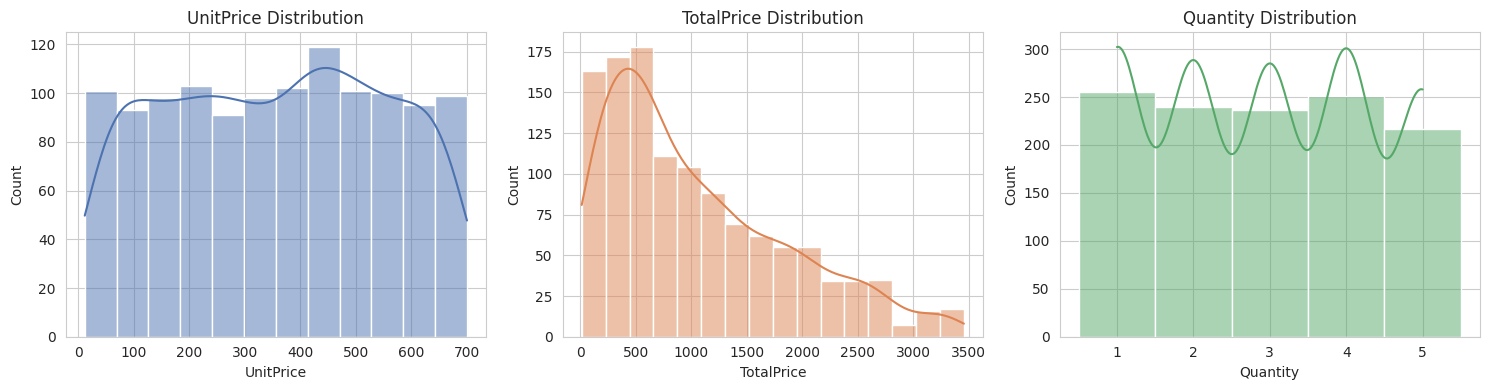

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['UnitPrice'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('UnitPrice Distribution')

sns.histplot(df['TotalPrice'], kde=True, ax=axes[1], color='#DD8452')
axes[1].set_title('TotalPrice Distribution')

sns.histplot(df['Quantity'], kde=True, ax=axes[2], color='#55A868', discrete=True)
axes[2].set_title('Quantity Distribution')

plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()

**Finding:** `UnitPrice` is close to uniform/symmetrical across its range. `TotalPrice` is right-skewed, confirming the mean/median gap noted above — this comes from `TotalPrice` being a product of `Quantity` and `UnitPrice`, so a handful of high-quantity, high-price orders create a long right tail. `Quantity` is roughly uniform between 1 and 5.

**Decision:** For `TotalPrice`, median (\$823.62) is the more representative "typical order" figure than mean (\$1,053.97) when communicating to stakeholders.

## 3. Outlier Detection — IQR Method

Using the standard rule: a value is an outlier if it falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR.

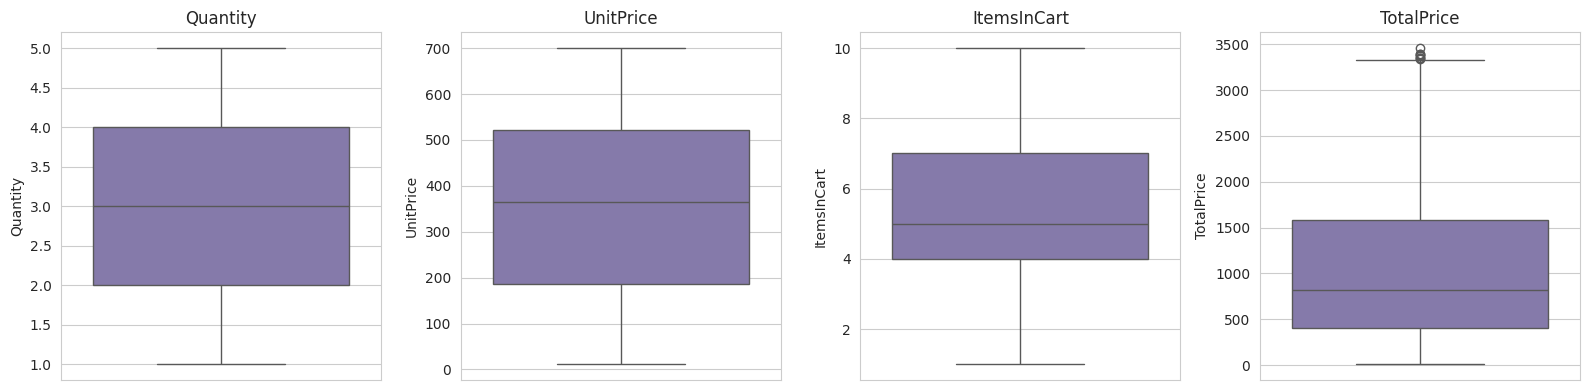

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#8172B2')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

for col in numeric_cols:
    outliers, lower, upper = iqr_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers  (expected range: {lower:.2f} to {upper:.2f})")

Quantity: 0 outliers  (expected range: -1.00 to 7.00)
UnitPrice: 0 outliers  (expected range: -317.20 to 1024.83)
ItemsInCart: 0 outliers  (expected range: -0.50 to 11.50)
TotalPrice: 8 outliers  (expected range: -1341.41 to 3330.41)


**Finding:** Only `TotalPrice` has outliers — 8 orders (0.67% of the dataset) fall above the upper bound of \$3,330.41, with the highest at \$3,456.40. `UnitPrice`, `Quantity`, and `ItemsInCart` have zero flagged outliers.

**Noise or signal?** These 8 orders combine both high `Quantity` and high `UnitPrice` — they look like genuine large purchases, not data entry errors (no negative values, no impossible quantities). **Decision: signal, not noise** — worth investigating as potential high-value customers rather than cleaning them out.

## 4. Correlation Analysis

Measuring linear relationships between numeric columns with the Pearson correlation coefficient.

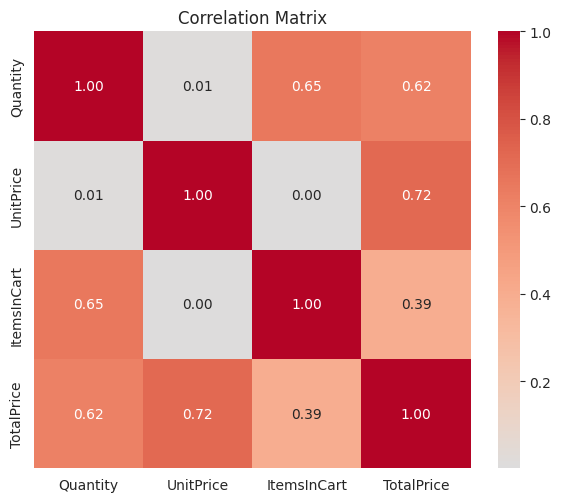

In [8]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

**Finding:**
- `UnitPrice` ↔ `TotalPrice`: **r = 0.72** (strong positive) — expected, since TotalPrice is derived from UnitPrice.
- `Quantity` ↔ `TotalPrice`: **r = 0.62** (moderate-strong positive) — also expected, same reason.
- `Quantity` ↔ `ItemsInCart`: **r = 0.65** (moderate-strong positive) — customers who order more units also tend to have more items in cart, plausible browsing behavior.
- `UnitPrice` ↔ `Quantity`: **r = 0.01** (essentially none) — customers don't systematically buy more units of cheaper items, or vice versa.

**Caution:** Correlation is not causation. `UnitPrice` and `Quantity` both correlating with `TotalPrice` is a mathematical artifact of how TotalPrice is calculated (`Quantity × UnitPrice`), not an independent business insight — this needs to be stated explicitly rather than presented as a genuine discovery.

## 5. Trends

Looking at order patterns over time and across key categorical columns.

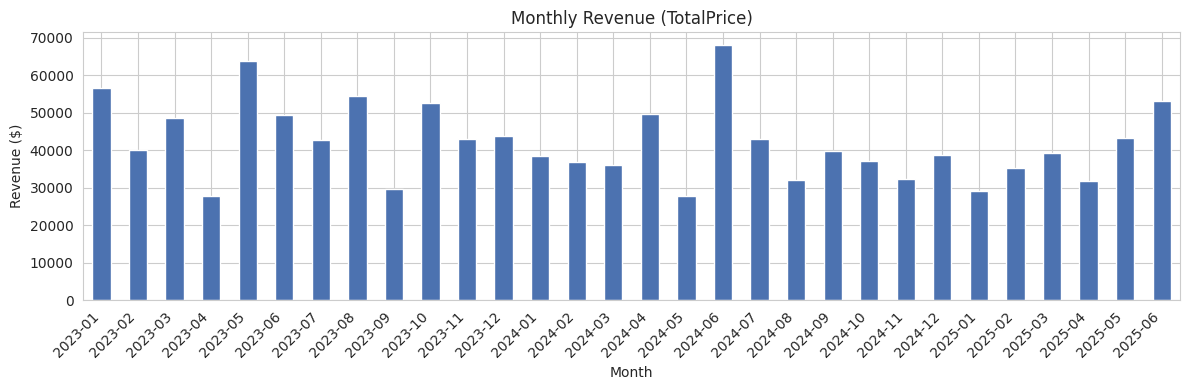

In [9]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(12, 4))
monthly_revenue.plot(kind='bar', color='#4C72B0')
plt.title('Monthly Revenue (TotalPrice)')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=100, bbox_inches='tight')
plt.show()

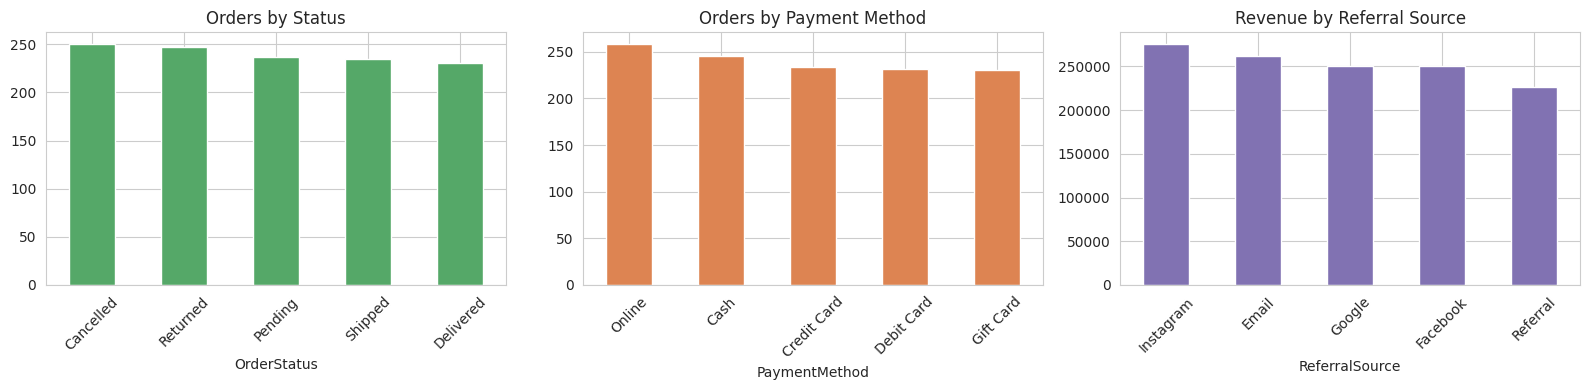

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['OrderStatus'].value_counts().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Orders by Status')
axes[0].tick_params(axis='x', rotation=45)

df['PaymentMethod'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Orders by Payment Method')
axes[1].tick_params(axis='x', rotation=45)

df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='#8172B2')
axes[2].set_title('Revenue by Referral Source')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('categorical_trends.png', dpi=100, bbox_inches='tight')
plt.show()

**Findings:**
- **Revenue by month** fluctuates with no strong seasonal trend visible across the 2023–2025 window in this sample — highest month is June 2024 (\$68,068.54), lowest is April 2023 (\$27,751.71).
- **Order status** is fairly evenly split — Cancelled (250) and Returned (247) together account for **41% of all orders**, which is a meaningfully high combined rate worth flagging.
- **Payment method** is evenly distributed across all 5 methods (roughly 230–258 orders each) — no single method dominates.
- **Referral source revenue**: Instagram leads at \$275,285, followed by Email (\$261,809) and Google (\$250,441). Referral (word-of-mouth) generates the least revenue at \$226,816.

## 6. Summary of Key Observations — The "So What?" Test

| What the data says | The business diagnosis |
|---|---|
| TotalPrice mean (\$1,053.97) is notably above its median (\$823.62) | A small number of large orders skew the average upward — reporting "average order value" alone overstates the typical customer's spend. Use median for typical-order reporting. |
| 8 orders (0.67%) are statistical outliers on TotalPrice, all with high Quantity × high UnitPrice | These are not data errors — they're likely high-value customers. Worth a targeted look for a VIP/loyalty program rather than exclusion from analysis. |
| Cancelled + Returned orders = 41% of all orders | This is a high combined rate. If this pattern holds beyond this sample, it points to a real operational problem (fulfillment, product-fit, or checkout experience) worth investigating before scaling marketing spend. |
| Instagram is the top revenue-generating referral source (\$275K) | If customer acquisition cost data were available, this would justify evaluating whether to shift more acquisition budget toward Instagram. |
| UnitPrice and Quantity are essentially uncorrelated (r = 0.01) | Customers aren't bulk-buying cheaper items disproportionately — pricing strategy doesn't need to account for a quantity-discount-seeking behavior pattern in this data. |

## 7. Executive Summary

**Problem Statement:** Understand order value patterns, order fulfillment issues, and revenue drivers in the cleaned e-commerce orders dataset to surface actionable business insight.

**Methodology:** Loaded the Project 1 cleaned dataset (1,200 orders, 0 missing values, 0 duplicates). Computed descriptive statistics and distribution shape for all numeric fields, detected outliers via the IQR method, ran Pearson correlation analysis across numeric fields, and examined trends across time and key categorical fields (order status, payment method, referral source).

**Key Findings:**
1. TotalPrice is right-skewed (mean \$1,053.97 vs. median \$823.62) — median is the more honest "typical order" metric.
2. 8 high-value orders (0.67%) are statistical outliers but appear to be genuine large purchases, not data errors.
3. Cancelled + Returned orders combined make up 41% of all orders — the single most concerning finding in this dataset.
4. Instagram is the strongest referral source by revenue (\$275,285); Referral (word-of-mouth) is the weakest (\$226,816).
5. UnitPrice and Quantity move independently of each other (r ≈ 0.01) — no bulk-buying-discount-seeking pattern present.

**Recommendations:**
1. Investigate the 41% cancelled/returned rate as a priority — this is the finding with the clearest operational impact.
2. Report median order value, not mean, when communicating "typical" order size to avoid overstating customer spend.
3. Consider a targeted follow-up on the 8 high-value outlier orders to understand if they represent a repeatable high-value customer segment.
4. If acquisition cost data becomes available, evaluate reallocating marketing spend toward Instagram given its lead in referral revenue.